# SCNN v6 — Few-Shot Calibration Pipeline

Approach: pre-train strong base model → fine-tune with minimal calibration data (1 rep = 7 trials) per target condition.

Consistent across all scenarios:
- **Calibration data**: 1 repetition per gesture (7 trials, ~700 windows)
- **Fine-tune strategy**: freeze feature extractor, retrain classifier only, 10 epochs
- **Test**: remaining data from target condition

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import copy
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import (
    MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE,
    SUBJECTS_INTERDAY_LONG,
)
from src.data_splitter import (
    load_metadata, load_windows_from_metadata,
    compute_normalization_stats, apply_normalization,
)
from src.feature_extraction import fht_envelope_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model (same SCNN-ECA as v4/v5)

In [2]:
class ECAModule(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k = int(abs(math.log2(channels) / gamma + b / gamma))
        k = k if k % 2 else k + 1
        k = max(k, 3)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
    def forward(self, x):
        b, c, h, w = x.size()
        y = self.avg_pool(x).view(b, 1, c)
        y = torch.sigmoid(self.conv(y)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))

class SCNN_ECA(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(1, 48, 3, 1), nn.BatchNorm2d(48), nn.ReLU(),
            ECAModule(48), nn.MaxPool2d(2),
            DepthwiseSeparableConv(48, 96, 3, 1), nn.BatchNorm2d(96), nn.ReLU(),
            ECAModule(96), nn.MaxPool2d(2),
            DepthwiseSeparableConv(96, 192, 3, 1), nn.BatchNorm2d(192), nn.ReLU(),
            ECAModule(192), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(192, 96), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(96, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

print(f"Parameters: {sum(p.numel() for p in SCNN_ECA().parameters()):,}")

Parameters: 44,764


## Core functions

In [3]:
def make_loader(X_fht, y, batch_size=256, shuffle=True):
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    y_t = torch.from_numpy(y).long()
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_base(model, loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(loader)
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Base epoch {epoch+1:3d}/{n_epochs} — loss: {total_loss/total:.4f}, acc: {correct/total:.4f}")


def finetune(model, X_cal_fht, y_cal, n_epochs=10, lr=1e-4):
    """Fine-tune classifier only, freeze features."""
    model = copy.deepcopy(model)
    model.to(DEVICE)

    # Freeze feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loader = make_loader(X_cal_fht, y_cal, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(n_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Unfreeze for future use
    for param in model.features.parameters():
        param.requires_grad = True
    return model


@torch.no_grad()
def predict(model, X_fht):
    model.eval()
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

## Helper: load & preprocess subsets from metadata

In [4]:
META = load_metadata()

def load_and_prep(df, norm_stats=None):
    """Load windows, normalize, apply FHT. Returns X_fht, y, norm_stats."""
    X, y = load_windows_from_metadata(df, verbose=False)
    if norm_stats is None:
        mean, std = compute_normalization_stats(X)
        norm_stats = (mean, std)
    X = apply_normalization(X, norm_stats[0], norm_stats[1])
    X_fht = fht_envelope_batch(X)
    return X_fht, y, norm_stats

---
## Step 1: Pre-train base model on ALL available data

Use all subjects, session 0, all positions, rep 0-1. This is the largest possible training set without touching any test data.

In [5]:
base_df = META[(META["session"] == 0) & (META["repetition"].isin([0, 1]))]
print(f"Base training set: {len(base_df)} trials")

X_base, y_base, base_norm = load_and_prep(base_df)
print(f"Windows: {X_base.shape}")

base_model = SCNN_ECA().to(DEVICE)
loader_base = make_loader(X_base, y_base)
train_base(base_model, loader_base, n_epochs=50)

torch.save(base_model.state_dict(), MODELS_DIR / "scnn_v6_base.pt")
print("Base model saved.")

Base training set: 5539 trials
Windows: (646288, 8, 50)
  Base epoch   1/50 — loss: 1.5893, acc: 0.4246
  Base epoch  10/50 — loss: 1.2446, acc: 0.6163
  Base epoch  20/50 — loss: 1.1890, acc: 0.6469
  Base epoch  30/50 — loss: 1.1420, acc: 0.6710
  Base epoch  40/50 — loss: 1.0875, acc: 0.6995
  Base epoch  50/50 — loss: 1.0569, acc: 0.7157
Base model saved.


---
## Scenario 1 — Ideal (per-subject with calibration)

- Base model: pre-trained above
- Calibration: rep 0 from target subject (7 trials)
- Test: rep 2 from target subject
- Compare: with vs without fine-tuning

In [6]:
subset_s1 = META[(META["session"] == 0) & (META["position"] == 0)]
subjects = sorted(subset_s1["subject"].unique())

acc_no_ft = {}  # without fine-tuning
acc_ft = {}     # with fine-tuning

for subj in subjects:
    subj_df = subset_s1[subset_s1["subject"] == subj]

    cal_df = subj_df[subj_df["repetition"] == 0]   # calibration: 1 rep
    test_df = subj_df[subj_df["repetition"] == 2]   # test

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    # Without fine-tuning
    y_pred_base = predict(base_model, X_test)
    acc_no_ft[subj] = accuracy_score(y_test, y_pred_base)

    # With fine-tuning
    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred_ft = predict(ft_model, X_test)
    acc_ft[subj] = accuracy_score(y_test, y_pred_ft)

avg_no_ft = np.mean(list(acc_no_ft.values()))
avg_ft = np.mean(list(acc_ft.values()))

print(f"\nS1 Per-subject — Base model: {avg_no_ft:.4f}, After calibration: {avg_ft:.4f} (Δ = {avg_ft-avg_no_ft:+.4f})")
print()
for subj in subjects:
    delta = acc_ft[subj] - acc_no_ft[subj]
    bar = "█" * int(acc_ft[subj] * 40)
    print(f"  {subj:4s}: base={acc_no_ft[subj]:.3f}  cal={acc_ft[subj]:.3f}  Δ={delta:+.3f}  {bar}")


S1 Per-subject — Base model: 0.6962, After calibration: 0.6353 (Δ = -0.0608)

  h0  : base=0.735  cal=0.708  Δ=-0.027  ████████████████████████████
  h1  : base=0.427  cal=0.340  Δ=-0.088  █████████████
  h10 : base=0.808  cal=0.789  Δ=-0.019  ███████████████████████████████
  h11 : base=0.556  cal=0.455  Δ=-0.101  ██████████████████
  h12 : base=0.527  cal=0.328  Δ=-0.199  █████████████
  h13 : base=0.652  cal=0.566  Δ=-0.086  ██████████████████████
  h14 : base=0.683  cal=0.830  Δ=+0.147  █████████████████████████████████
  h15 : base=0.657  cal=0.634  Δ=-0.023  █████████████████████████
  h16 : base=0.760  cal=0.657  Δ=-0.103  ██████████████████████████
  h17 : base=0.567  cal=0.519  Δ=-0.048  ████████████████████
  h18 : base=0.607  cal=0.534  Δ=-0.073  █████████████████████
  h19 : base=0.575  cal=0.632  Δ=+0.057  █████████████████████████
  h2  : base=0.681  cal=0.694  Δ=+0.013  ███████████████████████████
  h20 : base=0.488  cal=0.468  Δ=-0.020  ██████████████████
  h21 : base=

In [7]:
# Multi-subject S1 (train rep 0-1 from all, test rep 2 from all) — same as previous experiments
test_s1 = META[(META["session"] == 0) & (META["position"] == 0) & (META["repetition"] == 2)]
X_test_s1, y_test_s1, _ = load_and_prep(test_s1, norm_stats=base_norm)
y_pred_s1 = predict(base_model, X_test_s1)
metrics_s1 = print_report(y_test_s1, y_pred_s1, title="v6 Base — S1 Ideal (multi-subject, no calibration)")


  v6 Base — S1 Ideal (multi-subject, no calibration)
  Accuracy:  0.7002
  F1-macro:  0.7001
                    precision    recall  f1-score   support

              fist       0.79      0.79      0.79      4208
         open_hand       0.66      0.71      0.68      4179
  pinch_forefinger       0.62      0.64      0.63      4204
pinch_middlefinger       0.65      0.57      0.61      4239
               two       0.69      0.73      0.71      4175
          eversion       0.79      0.80      0.79      4064
             varus       0.70      0.67      0.68      4212

          accuracy                           0.70     29281
         macro avg       0.70      0.70      0.70     29281
      weighted avg       0.70      0.70      0.70     29281



---
## Scenario 2 — Electrode Shift (calibration per position)

- Base model: pre-trained above (already saw p0 + multiple subjects)
- Calibration: rep 0 from target position (7 trials per position)
- Test: rep 1-2 from target position

In [8]:
subset_s2 = META[(META["session"] == 0) & (META["subject"].isin(SUBJECTS_NON_FATIGUE))]

acc_s2_no_ft = {}
acc_s2_ft = {}

for pos in range(1, 11):
    pos_df = subset_s2[subset_s2["position"] == pos]

    cal_df = pos_df[pos_df["repetition"] == 0]    # calibration
    test_df = pos_df[pos_df["repetition"].isin([1, 2])]  # test

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    # Without fine-tuning
    y_pred_base = predict(base_model, X_test)
    acc_s2_no_ft[pos] = accuracy_score(y_test, y_pred_base)

    # With fine-tuning
    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred_ft = predict(ft_model, X_test)
    acc_s2_ft[pos] = accuracy_score(y_test, y_pred_ft)

    print(f"Position {pos:2d}: base={acc_s2_no_ft[pos]:.4f}  cal={acc_s2_ft[pos]:.4f}  Δ={acc_s2_ft[pos]-acc_s2_no_ft[pos]:+.4f}")

avg_s2_no_ft = np.mean(list(acc_s2_no_ft.values()))
avg_s2_ft = np.mean(list(acc_s2_ft.values()))
print(f"\nS2 avg — Base: {avg_s2_no_ft:.4f}, After calibration: {avg_s2_ft:.4f} (Δ = {avg_s2_ft-avg_s2_no_ft:+.4f})")

Position  1: base=0.6741  cal=0.6950  Δ=+0.0209
Position  2: base=0.6849  cal=0.7031  Δ=+0.0182
Position  3: base=0.6810  cal=0.6998  Δ=+0.0188
Position  4: base=0.6814  cal=0.6776  Δ=-0.0039
Position  5: base=0.6931  cal=0.6981  Δ=+0.0050
Position  6: base=0.7115  cal=0.6931  Δ=-0.0183
Position  7: base=0.7030  cal=0.7278  Δ=+0.0248
Position  8: base=0.6995  cal=0.7226  Δ=+0.0231
Position  9: base=0.7086  cal=0.7268  Δ=+0.0182
Position 10: base=0.7049  cal=0.7165  Δ=+0.0116

S2 avg — Base: 0.6942, After calibration: 0.7060 (Δ = +0.0118)


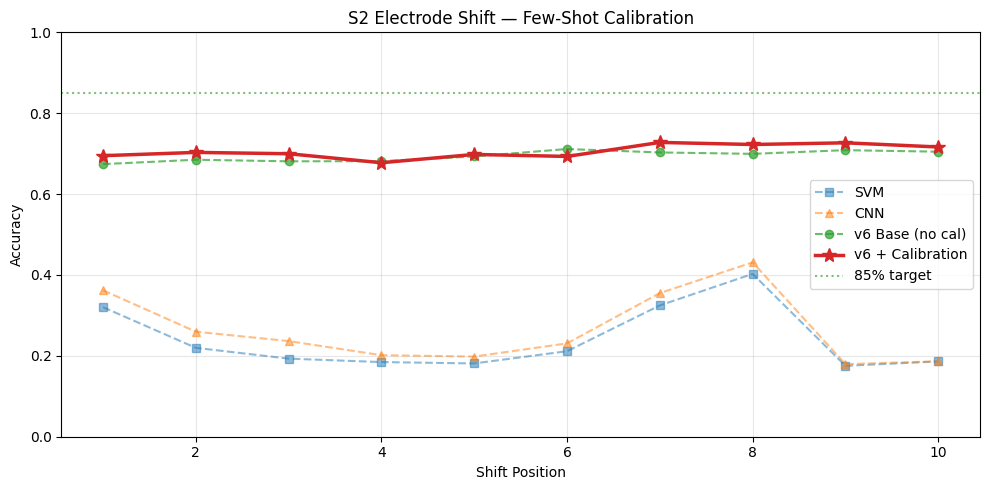

In [9]:
# S2 comparison plot
svm_shift = [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_shift = [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]

positions = list(range(1, 11))
plt.figure(figsize=(10, 5))
plt.plot(positions, svm_shift, "s--", label="SVM", alpha=0.5)
plt.plot(positions, cnn_shift, "^--", label="CNN", alpha=0.5)
plt.plot(positions, [acc_s2_no_ft[p] for p in positions], "o--", label="v6 Base (no cal)", alpha=0.7)
plt.plot(positions, [acc_s2_ft[p] for p in positions], "*-", label="v6 + Calibration", linewidth=2.5, markersize=10)
plt.axhline(y=0.85, color="green", linestyle=":", alpha=0.5, label="85% target")
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("S2 Electrode Shift — Few-Shot Calibration")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "v6_s2_calibration.png"), dpi=150)
plt.show()

---
## Scenario 3 — Inter-Subject (calibration per subject)

- Base model: pre-trained above
- Test subjects: same 6 from previous experiments
- Calibration: rep 0 from test subject, session 0, p0 (7 trials only!)
- Test: rep 1-2 from test subject, all positions

In [10]:
# Use same test subjects as previous experiments
rng = np.random.RandomState(RANDOM_SEED)
all_subjects = sorted(META[META["subject"].isin(SUBJECTS_NON_FATIGUE)]["subject"].unique())
test_subjects = list(rng.choice(all_subjects, size=6, replace=False))
print(f"Test subjects: {test_subjects}")

subset_s3 = META[(META["session"] == 0) & (META["subject"].isin(test_subjects))]

acc_s3_no_ft = {}
acc_s3_ft = {}

for subj in test_subjects:
    subj_df = subset_s3[subset_s3["subject"] == subj]

    # Calibration: rep 0, position 0 only (minimal: 7 trials)
    cal_df = subj_df[(subj_df["repetition"] == 0) & (subj_df["position"] == 0)]
    # Test: rep 1-2, all positions
    test_df = subj_df[subj_df["repetition"].isin([1, 2])]

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    # Without fine-tuning
    y_pred_base = predict(base_model, X_test)
    acc_s3_no_ft[subj] = accuracy_score(y_test, y_pred_base)

    # With fine-tuning
    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred_ft = predict(ft_model, X_test)
    acc_s3_ft[subj] = accuracy_score(y_test, y_pred_ft)

    print(f"  {subj}: base={acc_s3_no_ft[subj]:.4f}  cal={acc_s3_ft[subj]:.4f}  Δ={acc_s3_ft[subj]-acc_s3_no_ft[subj]:+.4f}")

avg_s3_no_ft = np.mean(list(acc_s3_no_ft.values()))
avg_s3_ft = np.mean(list(acc_s3_ft.values()))
print(f"\nS3 avg — Base: {avg_s3_no_ft:.4f}, After calibration: {avg_s3_ft:.4f} (Δ = {avg_s3_ft-avg_s3_no_ft:+.4f})")

Test subjects: ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']
  h7: base=0.7067  cal=0.5175  Δ=-0.1892
  h22: base=0.6973  cal=0.4705  Δ=-0.2267
  h3: base=0.7324  cal=0.4667  Δ=-0.2657
  h24: base=0.7384  cal=0.5303  Δ=-0.2081
  h16: base=0.6695  cal=0.4947  Δ=-0.1748
  h17: base=0.6735  cal=0.4692  Δ=-0.2043

S3 avg — Base: 0.7029, After calibration: 0.4915 (Δ = -0.2115)


In [11]:
# Pooled S3 metrics for comparison table
all_y_true, all_y_pred = [], []
for subj in test_subjects:
    subj_df = subset_s3[subset_s3["subject"] == subj]
    test_df = subj_df[subj_df["repetition"].isin([1, 2])]
    cal_df = subj_df[(subj_df["repetition"] == 0) & (subj_df["position"] == 0)]

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred = predict(ft_model, X_test)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

metrics_s3 = print_report(np.array(all_y_true), np.array(all_y_pred), title="v6 — S3 Inter-Subject + Calibration")


  v6 — S3 Inter-Subject + Calibration
  Accuracy:  0.4887
  F1-macro:  0.4770
                    precision    recall  f1-score   support

              fist       0.53      0.41      0.46     15957
         open_hand       0.45      0.56      0.50     15940
  pinch_forefinger       0.44      0.23      0.30     16235
pinch_middlefinger       0.52      0.29      0.37     16043
               two       0.59      0.63      0.61     16078
          eversion       0.58      0.72      0.64     15944
             varus       0.36      0.59      0.45     16054

          accuracy                           0.49    112251
         macro avg       0.50      0.49      0.48    112251
      weighted avg       0.50      0.49      0.48    112251



---
## Scenario 4 — Inter-Day (calibration per session)

- Base model: pre-trained above (includes h0-h5 session 0)
- Calibration: rep 0 from target session, p0 (7 trials)
- Test: rep 1-2 from target session, p0

In [12]:
subset_s4 = META[(META["subject"].isin(SUBJECTS_INTERDAY_LONG)) & (META["position"] == 0)]

acc_s4_no_ft = {}
acc_s4_ft = {}

for sess in range(1, 10):
    sess_df = subset_s4[subset_s4["session"] == sess]

    cal_df = sess_df[sess_df["repetition"] == 0]
    test_df = sess_df[sess_df["repetition"].isin([1, 2])]

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    y_pred_base = predict(base_model, X_test)
    acc_s4_no_ft[sess] = accuracy_score(y_test, y_pred_base)

    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred_ft = predict(ft_model, X_test)
    acc_s4_ft[sess] = accuracy_score(y_test, y_pred_ft)

    print(f"Session {sess}: base={acc_s4_no_ft[sess]:.4f}  cal={acc_s4_ft[sess]:.4f}  Δ={acc_s4_ft[sess]-acc_s4_no_ft[sess]:+.4f}")

avg_s4_no_ft = np.mean(list(acc_s4_no_ft.values()))
avg_s4_ft = np.mean(list(acc_s4_ft.values()))
print(f"\nS4 avg — Base: {avg_s4_no_ft:.4f}, After calibration: {avg_s4_ft:.4f} (Δ = {avg_s4_ft-avg_s4_no_ft:+.4f})")

Session 1: base=0.5776  cal=0.6288  Δ=+0.0513
Session 2: base=0.6342  cal=0.6882  Δ=+0.0540
Session 3: base=0.6128  cal=0.6729  Δ=+0.0601
Session 4: base=0.6059  cal=0.6683  Δ=+0.0624
Session 5: base=0.5804  cal=0.6754  Δ=+0.0950
Session 6: base=0.6254  cal=0.6697  Δ=+0.0443
Session 7: base=0.5847  cal=0.6607  Δ=+0.0760
Session 8: base=0.6432  cal=0.7031  Δ=+0.0599
Session 9: base=0.5869  cal=0.6815  Δ=+0.0946

S4 avg — Base: 0.6057, After calibration: 0.6721 (Δ = +0.0664)


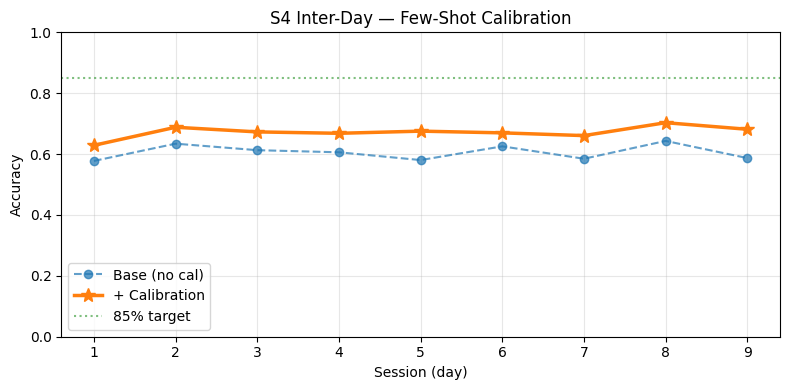

In [13]:
# S4 plot
sessions = list(range(1, 10))
plt.figure(figsize=(8, 4))
plt.plot(sessions, [acc_s4_no_ft[s] for s in sessions], "o--", label="Base (no cal)", alpha=0.7)
plt.plot(sessions, [acc_s4_ft[s] for s in sessions], "*-", label="+ Calibration", linewidth=2.5, markersize=10)
plt.axhline(y=0.85, color="green", linestyle=":", alpha=0.5, label="85% target")
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("S4 Inter-Day — Few-Shot Calibration")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "v6_s4_interday.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue (calibration per fatigue level)

- Base model: pre-trained above
- Calibration: rep 0 from target position
- Test: rep 1-2 from target position

In [14]:
subset_s5 = META[META["subject"].isin(SUBJECTS_FATIGUE)]

acc_s5_no_ft = {}
acc_s5_ft = {}

for pos in range(2, 11):
    pos_df = subset_s5[subset_s5["position"] == pos]

    cal_df = pos_df[pos_df["repetition"] == 0]
    test_df = pos_df[pos_df["repetition"].isin([1, 2])]

    X_cal, y_cal, _ = load_and_prep(cal_df, norm_stats=base_norm)
    X_test, y_test, _ = load_and_prep(test_df, norm_stats=base_norm)

    y_pred_base = predict(base_model, X_test)
    acc_s5_no_ft[pos] = accuracy_score(y_test, y_pred_base)

    ft_model = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-4)
    y_pred_ft = predict(ft_model, X_test)
    acc_s5_ft[pos] = accuracy_score(y_test, y_pred_ft)

    print(f"Position {pos:2d}: base={acc_s5_no_ft[pos]:.4f}  cal={acc_s5_ft[pos]:.4f}  Δ={acc_s5_ft[pos]-acc_s5_no_ft[pos]:+.4f}")

avg_s5_no_ft = np.mean(list(acc_s5_no_ft.values()))
avg_s5_ft = np.mean(list(acc_s5_ft.values()))
print(f"\nS5 avg — Base: {avg_s5_no_ft:.4f}, After calibration: {avg_s5_ft:.4f} (Δ = {avg_s5_ft-avg_s5_no_ft:+.4f})")

Position  2: base=0.8880  cal=0.8843  Δ=-0.0037
Position  3: base=0.8874  cal=0.8829  Δ=-0.0045
Position  4: base=0.9008  cal=0.8830  Δ=-0.0178
Position  5: base=0.9098  cal=0.8802  Δ=-0.0296
Position  6: base=0.8938  cal=0.8764  Δ=-0.0174
Position  7: base=0.9021  cal=0.8814  Δ=-0.0207
Position  8: base=0.8847  cal=0.8668  Δ=-0.0179
Position  9: base=0.9068  cal=0.8841  Δ=-0.0227
Position 10: base=0.8797  cal=0.8722  Δ=-0.0075

S5 avg — Base: 0.8948, After calibration: 0.8790 (Δ = -0.0158)


---
## Latency

In [15]:
base_model.eval()
sample_raw = np.random.randn(1, 8, 50).astype(np.float32)
sample_fht = torch.from_numpy(fht_envelope_batch(sample_raw)).float().unsqueeze(1).to(DEVICE)

for _ in range(10):
    _ = base_model(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def v6_predict_single(x_raw):
    x_fht = fht_envelope_batch(x_raw)
    x_t = torch.from_numpy(x_fht).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        out = base_model(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(v6_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNN-ECA v6 (inference, post-calibration)")
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"Note: calibration is one-time setup (~2 sec), does not affect inference latency.")


Latency — SCNN-ECA v6 (inference, post-calibration)
  Mean:   1.41 ms
  Median: 1.30 ms
  P95:    1.98 ms
  <300ms: ✓
Parameters: 44,764
Note: calibration is one-time setup (~2 sec), does not affect inference latency.


---
## Full Comparison

In [16]:
n_params = sum(p.numel() for p in base_model.parameters())

print("\n" + "=" * 80)
print("FULL COMPARISON — ALL METHODS")
print("=" * 80)
print(f"{'Metric':<22} {'SVM':>8} {'CNN':>8} {'v4':>8} {'v5+cal':>8} {'v6+fewshot':>10}")
print("-" * 80)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'76.32%':>8} {'76.32%':>8} {metrics_s1['accuracy']*100:>9.2f}%")
print(f"{'S1 Per-subj (cal)':<22} {'77.70%':>8} {'—':>8} {'—':>8} {'81.75%':>8} {avg_ft*100:>9.2f}%")
print(f"{'S2 Shift (avg cal)':<22} {'23.99%':>8} {'26.41%':>8} {'32.27%':>8} {'57.18%':>8} {avg_s2_ft*100:>9.2f}%")
print(f"{'S3 Inter-subj (cal)':<22} {'40.27%':>8} {'52.90%':>8} {'46.70%':>8} {'51.15%':>8} {avg_s3_ft*100:>9.2f}%")
print(f"{'S4 Inter-day (cal)':<22} {'63.03%':>8} {'67.30%':>8} {'65.60%':>8} {'61.22%':>8} {avg_s4_ft*100:>9.2f}%")
print(f"{'S5 Fatigue (cal)':<22} {'81.20%':>8} {'86.98%':>8} {'87.46%':>8} {'85.10%':>8} {avg_s5_ft*100:>9.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'1.67':>8} {'1.47':>8} {latency['p95_ms']:>9.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'44,764':>8} {'44,764':>8} {n_params:>10,}")
print("=" * 80)
print(f"\nCalibration cost: 1 repetition per gesture (7 trials, ~30 seconds of user time).")
print(f"Fine-tuning cost: ~2 seconds on MPS (10 epochs, classifier only).")


FULL COMPARISON — ALL METHODS
Metric                      SVM      CNN       v4   v5+cal v6+fewshot
--------------------------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   76.32%   76.32%     70.02%
S1 Per-subj (cal)        77.70%        —        —   81.75%     63.53%
S2 Shift (avg cal)       23.99%   26.41%   32.27%   57.18%     70.60%
S3 Inter-subj (cal)      40.27%   52.90%   46.70%   51.15%     49.15%
S4 Inter-day (cal)       63.03%   67.30%   65.60%   61.22%     67.21%
S5 Fatigue (cal)         81.20%   86.98%   87.46%   85.10%     87.90%
Latency p95 (ms)           5.40     1.74     1.67     1.47      1.98
Parameters                    —  101,831   44,764   44,764     44,764

Calibration cost: 1 repetition per gesture (7 trials, ~30 seconds of user time).
Fine-tuning cost: ~2 seconds on MPS (10 epochs, classifier only).
